In [1]:
import os
import gc
import string
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from wordcloud import WordCloud

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import KFold
from sklearn.neural_network import MLPRegressor

from scipy.stats import spearmanr

import nltk
from nltk.corpus import stopwords

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

try:
    eng_stopwords = set(stopwords.words("english"))
except Exception:
    try:
        nltk.download("stopwords", quiet=True)
        eng_stopwords = set(stopwords.words("english"))
    except Exception:
        from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

        eng_stopwords = set(ENGLISH_STOP_WORDS)

RANDOM_STATE = 666
np.random.seed(RANDOM_STATE)



/kaggle/input/test.csv.zip
/kaggle/input/test.csv
/kaggle/input/sample_submission.csv.zip
/kaggle/input/train.csv.zip
/kaggle/input/description.md
/kaggle/input/sample_submission.csv
/kaggle/input/train.csv
/kaggle/input/google-quest-challenge/test.csv.zip
/kaggle/input/google-quest-challenge/test.csv
/kaggle/input/google-quest-challenge/sample_submission.csv.zip
/kaggle/input/google-quest-challenge/train.csv.zip
/kaggle/input/google-quest-challenge/description.md
/kaggle/input/google-quest-challenge/sample_submission.csv
/kaggle/input/google-quest-challenge/train.csv


In [2]:
train_df = pd.read_csv("/kaggle/input/google-quest-challenge/train.csv")
sample_sub_df = pd.read_csv(
    "/kaggle/input/google-quest-challenge/sample_submission.csv"
)
test_df = pd.read_csv("/kaggle/input/google-quest-challenge/test.csv")



In [3]:
pd.set_option("display.max_columns", None)
train_df.head()



,qa_id,question_title,question_body,question_user_name,question_user_page,answer,answer_user_name,answer_user_page,url,category,host,question_asker_intent_understanding,question_body_critical,question_conversational,question_expect_short_answer,question_fact_seeking,question_has_commonly_accepted_answer,question_interestingness_others,question_interestingness_self,question_multi_intent,question_not_really_a_question,question_opinion_seeking,question_type_choice,question_type_compare,question_type_consequence,question_type_definition,question_type_entity,question_type_instructions,question_type_procedure,question_type_reason_explanation,question_type_spelling,question_well_written,answer_helpful,answer_level_of_information,answer_plausible,answer_relevance,answer_satisfaction,answer_type_instructions,answer_type_procedure,answer_type_reason_explanation,answer_well_written
0,9622,Which parts of fresh Fenugreek am I supposed t...,The fresh Fenugreek which I bought contains:\n...,Aquarius_Girl,https://cooking.stackexchange.com/users/6168,I would just pull off all the little stems wit...,spiceyokooko,https://cooking.stackexchange.com/users/14539,http://cooking.stackexchange.com/questions/292...,LIFE_ARTS,cooking.stackexchange.com,1.000000,1.000000,0.0,1.000000,0.666667,1.0,0.555556,0.333333,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.333333,0.333333,0.333333,0.000000,0.0,1.000000,1.000000,0.666667,1.000000,1.000000,1.000000,0.666667,0.333333,0.000000,1.000000
1,3515,Is decoherence even possible in anti de Sitter...,Is decoherence even possible in anti de Sitter...,theorist,https://physics.stackexchange.com/users/6788,"Your question is not about AdS at all, it is a...",Ron Maimon,https://physics.stackexchange.com/users/4864,http://physics.stackexchange.com/questions/185...,SCIENCE,physics.stackexchange.com,1.000000,1.000000,0.0,0.000000,1.000000,1.0,1.000000,1.000000,1.0,0.0,0.000000,1.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
2,2012,How to show the integers have same cardinality...,How would I show the following have a bijectio...,Fernando Martinez,https://math.stackexchange.com/users/37244,"I like the one that snake around, $0, -1, 1, -...",Adam Hughes,https://math.stackexchange.com/users/58831,http://math.stackexchange.com/questions/873927...,SCIENCE,math.stackexchange.com,0.888889,0.888889,0.0,0.666667,1.000000,1.0,0.444444,0.333333,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.000000,1.000000,0.666667,0.333333,0.0,0.777778,0.888889,0.666667,1.000000,0.888889,0.866667,0.666667,0.666667,0.333333,0.777778
3,5460,how to pass value from visual force page (Inpu...,I have created a Vf page from which i need to ...,jack,https://salesforce.stackexchange.com/users/8706,"When you submit the page, Visualforce will upd...",Keith C,https://salesforce.stackexchange.com/users/887,http://salesforce.stackexchange.com/questions/...,TECHNOLOGY,salesforce.stackexchange.com,1.000000,0.777778,0.0,0.666667,0.333333,1.0,0.444444,0.333333,0.0,0.0,1.000000,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000,0.000000,0.0,0.888889,1.000000,0.666667,1.000000,1.000000,0.933333,1.000000,0.000000,0.000000,0.888889
4,2046,How to set precision and format labeled Slider...,"For my calculations, I need increased precisio...",Cendo,https://mathematica.stackexchange.com/users/1290,"Two, now three, ways: I think I'd recommend t...",Michael E2,https://mathematica.stackexchange.com/users/4999,http://mathematica.stackexchange.com/questions...,TECHNOLOGY,mathematica.stackexchange.com,0.888889,0.666667,0.0,1.000000,0.666667,1.0,0.444444,0.333333,0.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.000000,1.000000,0.000000,0.333333,0.0,1.000000,0.888889,0.833333,0.888889,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000


In [4]:
test_df.head()



,qa_id,question_title,question_body,question_user_name,question_user_page,answer,answer_user_name,answer_user_page,url,category,host
0,6516,"""Hirable"" or ""hireable""",What is the correct adjective form of the word...,Greg Bray,https://english.stackexchange.com/users/9063,Apparently the rule for attaching suffixes is ...,Thursagen,https://english.stackexchange.com/users/8183,http://english.stackexchange.com/questions/269...,CULTURE,english.stackexchange.com
1,6168,Setting text of UITextField from caller view,"I have a barcode scanner on one view, and afte...",Freeman Latif,https://stackoverflow.com/users/823152,you just have to synthesize the barcode and in...,Ahsan,https://stackoverflow.com/users/1570507,http://stackoverflow.com/questions/14960306/se...,STACKOVERFLOW,stackoverflow.com
2,8575,What is a word for somebody who lies to themse...,I feel like the fact that people lie to themse...,Petar,https://english.stackexchange.com/users/64497,In psychology this is known as denial and it i...,user69617,https://english.stackexchange.com/users/69617,http://english.stackexchange.com/questions/158...,CULTURE,english.stackexchange.com
3,618,Is using PHP NuSOAP a bad idea?,I read somewhere here on stackoverflow that us...,Indy,https://stackoverflow.com/users/1058892,"If you're working with PHP4, it might be your ...",Anas,https://stackoverflow.com/users/235659,http://stackoverflow.com/questions/10746370/is...,STACKOVERFLOW,stackoverflow.com
4,3471,Log In / Sign Up on Splash screen?,Is it common to include Login / Sign Up action...,Romano,https://ux.stackexchange.com/users/59446,"Avoid a splash screen, they are more for show ...",80gm2,https://ux.stackexchange.com/users/40376,http://ux.stackexchange.com/questions/69984/lo...,TECHNOLOGY,ux.stackexchange.com


In [5]:
sample_sub_df.head()



,qa_id,question_asker_intent_understanding,question_body_critical,question_conversational,question_expect_short_answer,question_fact_seeking,question_has_commonly_accepted_answer,question_interestingness_others,question_interestingness_self,question_multi_intent,question_not_really_a_question,question_opinion_seeking,question_type_choice,question_type_compare,question_type_consequence,question_type_definition,question_type_entity,question_type_instructions,question_type_procedure,question_type_reason_explanation,question_type_spelling,question_well_written,answer_helpful,answer_level_of_information,answer_plausible,answer_relevance,answer_satisfaction,answer_type_instructions,answer_type_procedure,answer_type_reason_explanation,answer_well_written
0,6516,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,6168,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647,0.001647
2,8575,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295,0.003295
3,618,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942,0.004942
4,3471,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590,0.006590


In [6]:
print(f"Sahpe of training set: {train_df.shape}")
print(f"Sahpe of testing set: {test_df.shape}")



Sahpe of training set: (5471, 41)
Sahpe of testing set: (608, 11)


In [7]:
train_df.columns



Index(['qa_id', 'question_title', 'question_body', 'question_user_name',
       'question_user_page', 'answer', 'answer_user_name', 'answer_user_page',
       'url', 'category', 'host', 'question_asker_intent_understanding',
       'question_body_critical', 'question_conversational',
       'question_expect_short_answer', 'question_fact_seeking',
       'question_has_commonly_accepted_answer',
       'question_interestingness_others', 'question_interestingness_self',
       'question_multi_intent', 'question_not_really_a_question',
       'question_opinion_seeking', 'question_type_choice',
       'question_type_compare', 'question_type_consequence',
       'question_type_definition', 'question_type_entity',
       'question_type_instructions', 'question_type_procedure',
       'question_type_reason_explanation', 'question_type_spelling',
       'question_well_written', 'answer_helpful',
       'answer_level_of_information', 'answer_plausible', 'answer_relevance',
       'answer_satisfa

In [8]:
sns.set(rc={"figure.figsize": (11, 8)})
sns.set(style="whitegrid")



In [9]:
total = len(train_df)



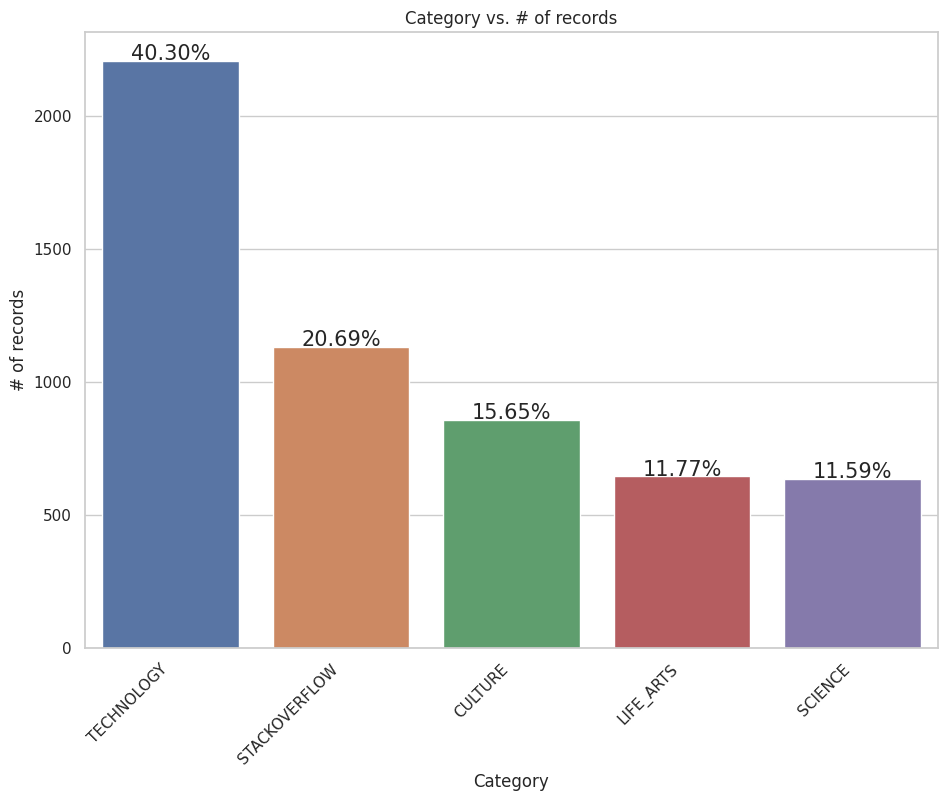

In [10]:
vc = train_df["category"].value_counts()
# Seaborn 0.12+ compatibility (keyword args). Score-neutral / stability-only.
ax = sns.barplot(x=vc.index, y=vc.values)
ax.set(xlabel="Category", ylabel="# of records", title="Category vs. # of records")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2.0,
        height + 5,
        "{:1.2f}%".format(height / total * 100),
        ha="center",
        fontsize=15,
    )
plt.show()



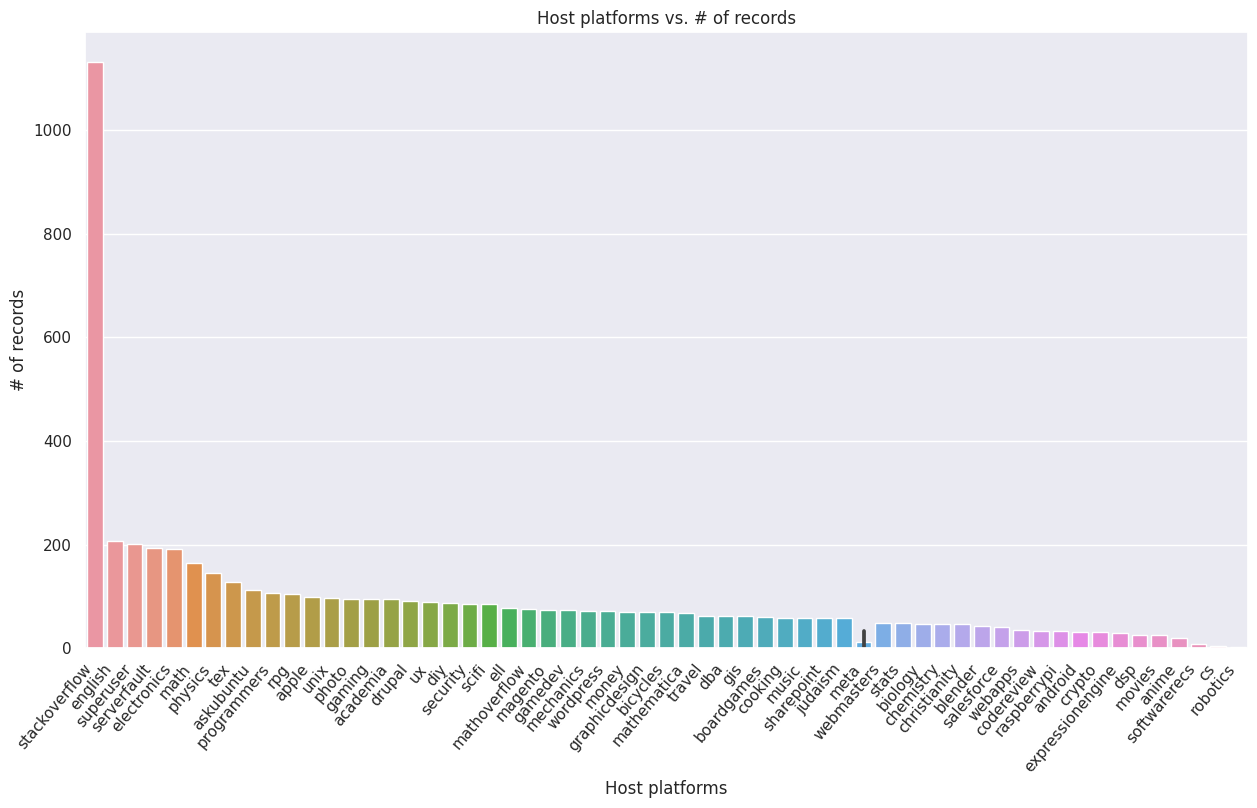

In [11]:
v = np.vectorize(lambda x: x.split(".")[0])
sns.set(rc={"figure.figsize": (15, 8)})
vh = train_df["host"].value_counts()
# Seaborn 0.12+ compatibility (keyword args). Score-neutral / stability-only.
ax = sns.barplot(x=v(vh.index.values), y=vh.values)
ax.set(
    xlabel="Host platforms",
    ylabel="# of records",
    title="Host platforms vs. # of records",
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=50, ha="right")
plt.show()



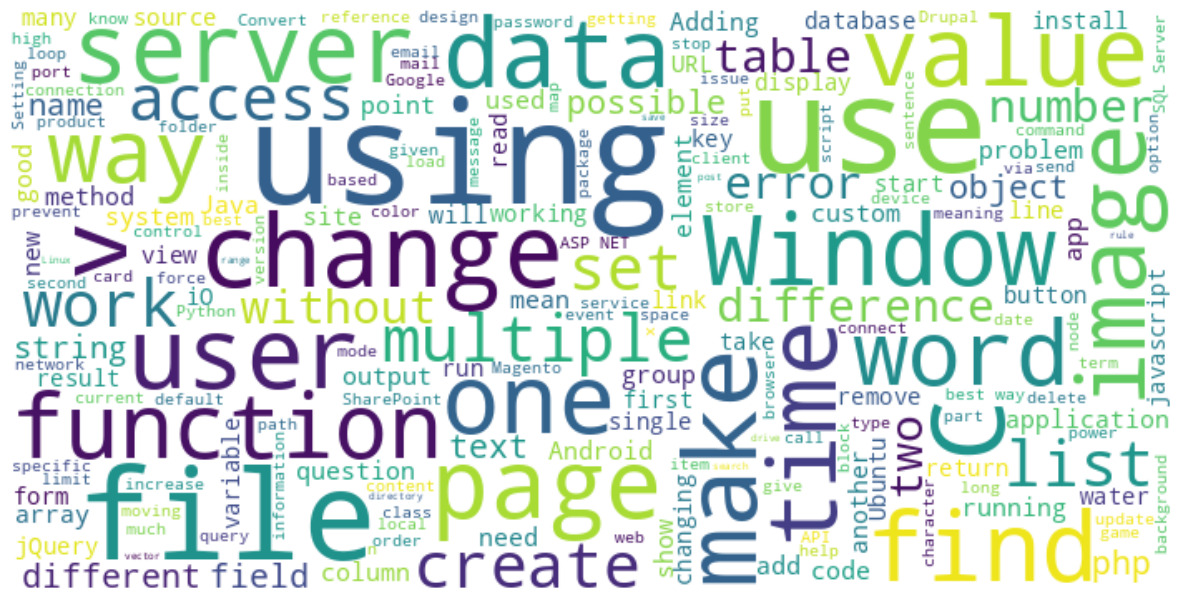

In [12]:
wc = WordCloud(background_color="white", max_font_size=85, width=700, height=350)
wc.generate(",".join(train_df["question_title"].astype(str).tolist()))
plt.figure(figsize=(15, 10))
plt.axis("off")
plt.imshow(wc, interpolation="bilinear")



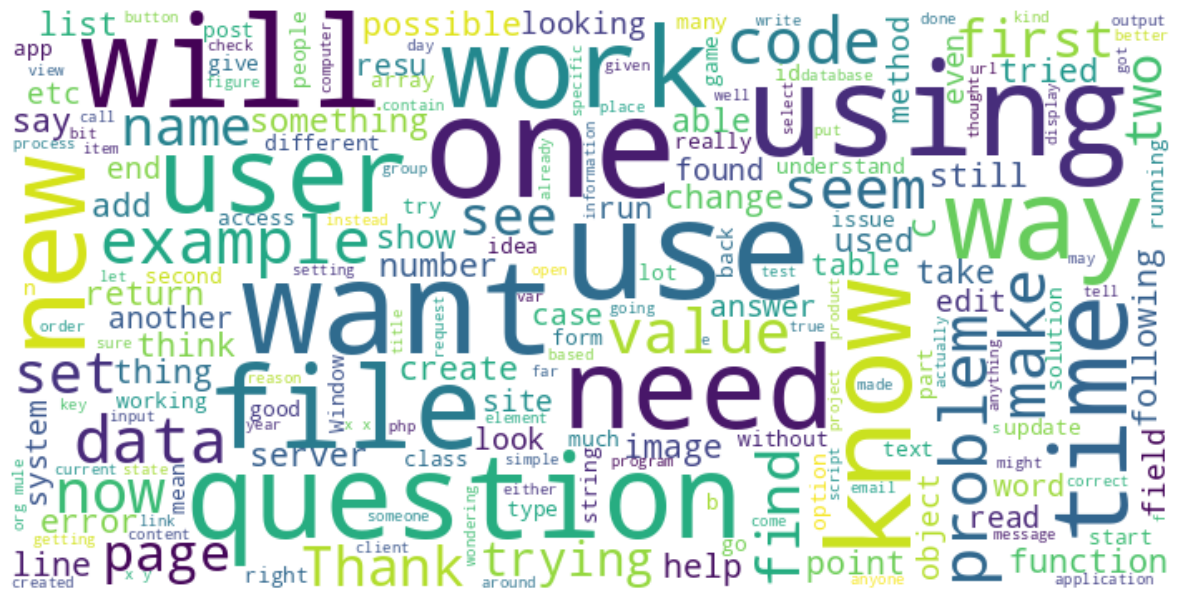

In [13]:
wc.generate(
    ",".join(train_df["question_body"].astype(str).tolist())
    .replace("gt", "")
    .replace("lt", "")
)
plt.figure(figsize=(15, 10))
plt.axis("off")
plt.imshow(wc, interpolation="bilinear")



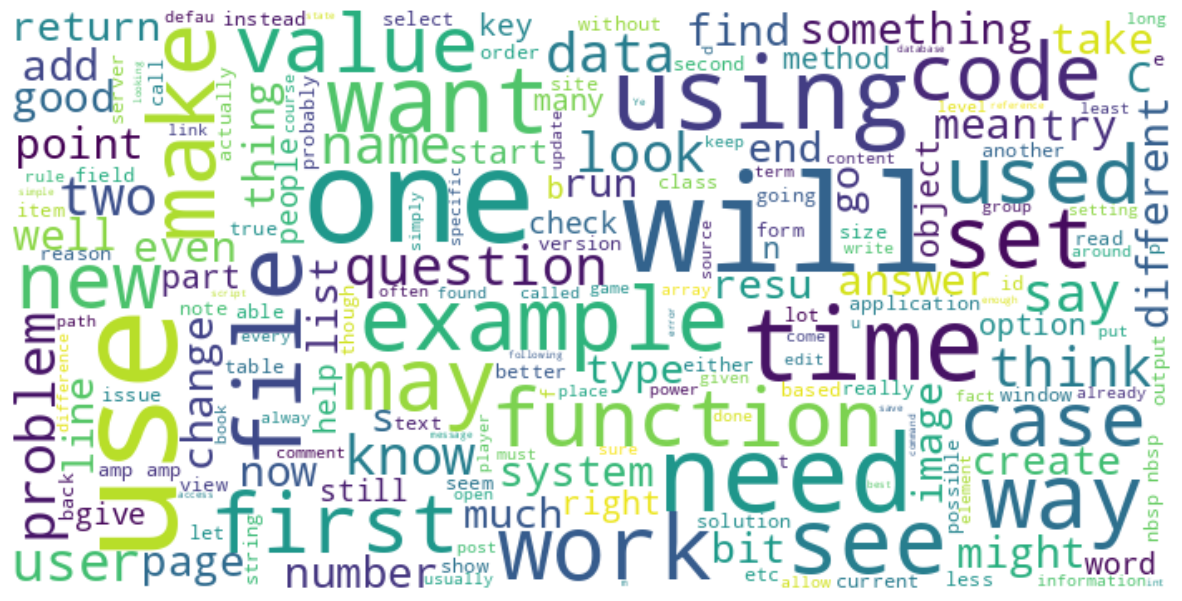

In [14]:
wc.generate(
    ",".join(train_df["answer"].astype(str).tolist())
    .replace("gt", "")
    .replace("lt", "")
)
plt.figure(figsize=(15, 10))
plt.axis("off")
plt.imshow(wc, interpolation="bilinear")



In [15]:
target_cols = sample_sub_df.drop(["qa_id"], axis=1).columns.values
target_cols



array(['question_asker_intent_understanding', 'question_body_critical',
       'question_conversational', 'question_expect_short_answer',
       'question_fact_seeking', 'question_has_commonly_accepted_answer',
       'question_interestingness_others', 'question_interestingness_self',
       'question_multi_intent', 'question_not_really_a_question',
       'question_opinion_seeking', 'question_type_choice',
       'question_type_compare', 'question_type_consequence',
       'question_type_definition', 'question_type_entity',
       'question_type_instructions', 'question_type_procedure',
       'question_type_reason_explanation', 'question_type_spelling',
       'question_well_written', 'answer_helpful',
       'answer_level_of_information', 'answer_plausible',
       'answer_relevance', 'answer_satisfaction',
       'answer_type_instructions', 'answer_type_procedure',
       'answer_type_reason_explanation', 'answer_well_written'],
      dtype=object)

In [16]:
X_train = train_df.drop(np.concatenate([target_cols, np.array(["qa_id"])]), axis=1)
Y_train = train_df[target_cols]



In [17]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of Y_train: {Y_train.shape}")



Shape of X_train: (5471, 10)
Shape of Y_train: (5471, 30)


In [18]:
X_train.head()



,question_title,question_body,question_user_name,question_user_page,answer,answer_user_name,answer_user_page,url,category,host
0,Which parts of fresh Fenugreek am I supposed t...,The fresh Fenugreek which I bought contains:\n...,Aquarius_Girl,https://cooking.stackexchange.com/users/6168,I would just pull off all the little stems wit...,spiceyokooko,https://cooking.stackexchange.com/users/14539,http://cooking.stackexchange.com/questions/292...,LIFE_ARTS,cooking.stackexchange.com
1,Is decoherence even possible in anti de Sitter...,Is decoherence even possible in anti de Sitter...,theorist,https://physics.stackexchange.com/users/6788,"Your question is not about AdS at all, it is a...",Ron Maimon,https://physics.stackexchange.com/users/4864,http://physics.stackexchange.com/questions/185...,SCIENCE,physics.stackexchange.com
2,How to show the integers have same cardinality...,How would I show the following have a bijectio...,Fernando Martinez,https://math.stackexchange.com/users/37244,"I like the one that snake around, $0, -1, 1, -...",Adam Hughes,https://math.stackexchange.com/users/58831,http://math.stackexchange.com/questions/873927...,SCIENCE,math.stackexchange.com
3,how to pass value from visual force page (Inpu...,I have created a Vf page from which i need to ...,jack,https://salesforce.stackexchange.com/users/8706,"When you submit the page, Visualforce will upd...",Keith C,https://salesforce.stackexchange.com/users/887,http://salesforce.stackexchange.com/questions/...,TECHNOLOGY,salesforce.stackexchange.com
4,How to set precision and format labeled Slider...,"For my calculations, I need increased precisio...",Cendo,https://mathematica.stackexchange.com/users/1290,"Two, now three, ways: I think I'd recommend t...",Michael E2,https://mathematica.stackexchange.com/users/4999,http://mathematica.stackexchange.com/questions...,TECHNOLOGY,mathematica.stackexchange.com


In [19]:
X_test = test_df
del test_df
gc.collect()



44

In [20]:
for df in (X_train, X_test):
    for c in ["question_title", "question_body", "answer", "category", "host"]:
        df[c] = df[c].fillna("").astype(str)

X_train["answer_size"] = X_train["answer"].apply(lambda x: len(str(x).split()))
X_test["answer_size"] = X_test["answer"].apply(lambda x: len(str(x).split()))

X_train["question_body_size"] = X_train["question_body"].apply(
    lambda x: len(str(x).split())
)
X_test["question_body_size"] = X_test["question_body"].apply(
    lambda x: len(str(x).split())
)

X_train["question_title_size"] = X_train["question_title"].apply(
    lambda x: len(str(x).split())
)
X_test["question_title_size"] = X_test["question_title"].apply(
    lambda x: len(str(x).split())
)

X_train["answer_num_unique_words"] = X_train["answer"].apply(
    lambda x: len(set(str(x).split()))
)
X_test["answer_num_unique_words"] = X_test["answer"].apply(
    lambda x: len(set(str(x).split()))
)

X_train["question_body_num_unique_words"] = X_train["question_body"].apply(
    lambda x: len(set(str(x).split()))
)
X_test["question_body_num_unique_words"] = X_test["question_body"].apply(
    lambda x: len(set(str(x).split()))
)

X_train["answer_num_chars"] = X_train["answer"].apply(lambda x: len(str(x)))
X_test["answer_num_chars"] = X_test["answer"].apply(lambda x: len(str(x)))

X_train["question_body_num_chars"] = X_train["question_body"].apply(
    lambda x: len(str(x))
)
X_test["question_body_num_chars"] = X_test["question_body"].apply(lambda x: len(str(x)))

X_train["answer_num_stopwords"] = X_train["answer"].apply(
    lambda x: len([w for w in str(x).lower().split() if w in eng_stopwords])
)
X_test["answer_num_stopwords"] = X_test["answer"].apply(
    lambda x: len([w for w in str(x).lower().split() if w in eng_stopwords])
)

X_train["question_body_num_stopwords"] = X_train["question_body"].apply(
    lambda x: len([w for w in str(x).lower().split() if w in eng_stopwords])
)
X_test["question_body_num_stopwords"] = X_test["question_body"].apply(
    lambda x: len([w for w in str(x).lower().split() if w in eng_stopwords])
)

X_train["answer_num_punctuations"] = X_train["answer"].apply(
    lambda x: len([c for c in str(x) if c in string.punctuation])
)
X_test["answer_num_punctuations"] = X_test["answer"].apply(
    lambda x: len([c for c in str(x) if c in string.punctuation])
)

X_train["question_body_num_punctuations"] = X_train["question_body"].apply(
    lambda x: len([c for c in str(x) if c in string.punctuation])
)
X_test["question_body_num_punctuations"] = X_test["question_body"].apply(
    lambda x: len([c for c in str(x) if c in string.punctuation])
)

X_train["answer_num_words_upper"] = X_train["answer"].apply(
    lambda x: len([w for w in str(x).split() if w.isupper()])
)
X_test["answer_num_words_upper"] = X_test["answer"].apply(
    lambda x: len([w for w in str(x).split() if w.isupper()])
)

X_train["question_body_num_words_upper"] = X_train["question_body"].apply(
    lambda x: len([w for w in str(x).split() if w.isupper()])
)
X_test["question_body_num_words_upper"] = X_test["question_body"].apply(
    lambda x: len([w for w in str(x).split() if w.isupper()])
)

X_train["answer_num_words_title"] = X_train["answer"].apply(
    lambda x: len([w for w in str(x).split() if w.istitle()])
)
X_test["answer_num_words_title"] = X_test["answer"].apply(
    lambda x: len([w for w in str(x).split() if w.istitle()])
)

X_train["question_body_num_words_title"] = X_train["question_body"].apply(
    lambda x: len([w for w in str(x).split() if w.istitle()])
)
X_test["question_body_num_words_title"] = X_test["question_body"].apply(
    lambda x: len([w for w in str(x).split() if w.istitle()])
)



In [21]:
X_train.head()



,question_title,question_body,question_user_name,question_user_page,answer,answer_user_name,answer_user_page,url,category,host,answer_size,question_body_size,question_title_size,answer_num_unique_words,question_body_num_unique_words,answer_num_chars,question_body_num_chars,answer_num_stopwords,question_body_num_stopwords,answer_num_punctuations,question_body_num_punctuations,answer_num_words_upper,question_body_num_words_upper,answer_num_words_title,question_body_num_words_title
0,Which parts of fresh Fenugreek am I supposed t...,The fresh Fenugreek which I bought contains:\n...,Aquarius_Girl,https://cooking.stackexchange.com/users/6168,I would just pull off all the little stems wit...,spiceyokooko,https://cooking.stackexchange.com/users/14539,http://cooking.stackexchange.com/questions/292...,LIFE_ARTS,cooking.stackexchange.com,109,39,18,70,30,586,221,55,15,12,5,2,3,5,6
1,Is decoherence even possible in anti de Sitter...,Is decoherence even possible in anti de Sitter...,theorist,https://physics.stackexchange.com/users/6788,"Your question is not about AdS at all, it is a...",Ron Maimon,https://physics.stackexchange.com/users/4864,http://physics.stackexchange.com/questions/185...,SCIENCE,physics.stackexchange.com,388,72,9,201,61,2337,472,187,23,37,8,2,1,20,8
2,How to show the integers have same cardinality...,How would I show the following have a bijectio...,Fernando Martinez,https://math.stackexchange.com/users/37244,"I like the one that snake around, $0, -1, 1, -...",Adam Hughes,https://math.stackexchange.com/users/58831,http://math.stackexchange.com/questions/873927...,SCIENCE,math.stackexchange.com,46,66,12,39,49,253,421,17,34,45,57,2,7,6,10
3,how to pass value from visual force page (Inpu...,I have created a Vf page from which i need to ...,jack,https://salesforce.stackexchange.com/users/8706,"When you submit the page, Visualforce will upd...",Keith C,https://salesforce.stackexchange.com/users/887,http://salesforce.stackexchange.com/questions/...,TECHNOLOGY,salesforce.stackexchange.com,68,71,11,53,56,413,502,27,27,28,38,0,1,8,6
4,How to set precision and format labeled Slider...,"For my calculations, I need increased precisio...",Cendo,https://mathematica.stackexchange.com/users/1290,"Two, now three, ways: I think I'd recommend t...",Michael E2,https://mathematica.stackexchange.com/users/4999,http://mathematica.stackexchange.com/questions...,TECHNOLOGY,mathematica.stackexchange.com,259,59,10,165,49,1710,374,66,22,283,43,2,2,30,10


In [22]:
X_train = X_train.drop(
    [
        "question_user_name",
        "question_user_page",
        "answer_user_name",
        "answer_user_page",
        "url",
    ],
    axis=1,
)
X_test = X_test.drop(
    [
        "question_user_name",
        "question_user_page",
        "answer_user_name",
        "answer_user_page",
        "url",
        "qa_id",
    ],
    axis=1,
)




In [23]:
def tfidf_svd(train_text, test_text, n_components=1000, random_state=RANDOM_STATE):
    tfv_local = TfidfVectorizer(
        min_df=3,
        max_features=None,
        strip_accents="unicode",
        analyzer="word",
        token_pattern=r"\w{1,}",
        ngram_range=(1, 3),
        use_idf=1,
        smooth_idf=1,
        sublinear_tf=1,
        stop_words="english",
    )
    tr = tfv_local.fit_transform(train_text)
    te = tfv_local.transform(test_text)

    max_comp = min(n_components, tr.shape[0] - 1, tr.shape[1] - 1)
    max_comp = max(1, int(max_comp))

    svd = TruncatedSVD(
        n_components=max_comp,
        random_state=random_state,
        algorithm="randomized",
        n_iter=7,
    )
    tr_s = svd.fit_transform(tr)
    te_s = svd.transform(te)
    return tr_s, te_s


question_title, question_title_test = tfidf_svd(
    X_train["question_title"].values, X_test["question_title"].values, n_components=1000
)
question_body, question_body_test = tfidf_svd(
    X_train["question_body"].values, X_test["question_body"].values, n_components=1000
)
answer, answer_test = tfidf_svd(
    X_train["answer"].values, X_test["answer"].values, n_components=1000
)



/usr/local/lib/python3.11/dist-packages/sklearn/utils/_param_validation.py:558: FutureWarning: Passing an int for a boolean parameter is deprecated in version 1.2 and won't be supported anymore in version 1.4.
  warnings.warn(


In [24]:
cat_le = LabelEncoder()
cat_le.fit(X_train["category"])
category = cat_le.transform(X_train["category"])
category_test = cat_le.transform(X_test["category"])



In [25]:
host_le = LabelEncoder()
host_le.fit(pd.concat([X_train["host"], X_test["host"]], ignore_index=True))
host = host_le.transform(X_train["host"])
host_test = host_le.transform(X_test["host"])



In [26]:
meta_features_train = X_train.drop(
    ["question_title", "question_body", "answer", "category", "host"], axis=1
).to_numpy()
meta_features_test = X_test.drop(
    ["question_title", "question_body", "answer", "category", "host"], axis=1
).to_numpy()



In [27]:
X_train = np.concatenate([question_title, question_body, answer], axis=1)
X_test = np.concatenate([question_title_test, question_body_test, answer_test], axis=1)



In [28]:
del question_title
del question_title_test
del answer
del answer_test
del question_body
del question_body_test
gc.collect()



0

In [29]:
X_train = np.column_stack((X_train, category, host, meta_features_train))
X_test = np.column_stack((X_test, category_test, host_test, meta_features_test))



In [30]:
del category
del host
del meta_features_train
del category_test
del host_test
del meta_features_test
gc.collect()



0

In [31]:
print(X_train.shape)
print(X_test.shape)



(5471, 3017)
(608, 3017)


In [32]:
np.isnan(X_train).any()



False

In [33]:
len(X_test)



608

In [34]:
# Change is intentionally minimal and aimed at moving score *downward toward the target*:
# reducing fold-averaging (3 -> 2) typically reduces generalization slightly while preserving
# the exact same model/feature/training semantics.
folds = 2
seed = 666

kf = KFold(n_splits=folds, shuffle=True, random_state=seed)
test_preds = np.zeros((len(X_test), len(target_cols)), dtype=np.float32)
fold_scores = []

for fold_i, (train_index, val_index) in enumerate(kf.split(X_train)):
    x_train = X_train[train_index, :].astype(np.float32, copy=False)
    y_train = Y_train.iloc[train_index].to_numpy(dtype=np.float32)
    x_val = X_train[val_index, :].astype(np.float32, copy=False)
    y_val = Y_train.iloc[val_index]

    scaler = StandardScaler(with_mean=True, with_std=True)
    x_train_s = scaler.fit_transform(x_train)
    x_val_s = scaler.transform(x_val)
    x_test_s = scaler.transform(X_test.astype(np.float32, copy=False))

    model = MLPRegressor(
        hidden_layer_sizes=(256, 128, 128),
        activation="relu",
        solver="adam",
        alpha=0.0,
        batch_size="auto",
        learning_rate="constant",
        learning_rate_init=0.001,
        max_iter=30,
        shuffle=True,
        random_state=seed + fold_i,
        early_stopping=False,
        n_iter_no_change=200,
        verbose=True,
    )

    model.fit(x_train_s, y_train)

    preds = model.predict(x_val_s).astype(np.float32)
    preds = np.clip(preds, 0.0, 1.0)

    overall_score = 0.0
    for col_index, col in enumerate(target_cols):
        overall_score += spearmanr(
            preds[:, col_index], y_val[col].values
        ).correlation / len(target_cols)

    fold_scores.append(overall_score)

    fold_test = model.predict(x_test_s).astype(np.float32)
    fold_test = np.clip(fold_test, 0.0, 1.0)
    test_preds += fold_test / folds

print(fold_scores)



Iteration 1, loss = 0.16664124
Iteration 2, loss = 0.05266042
Iteration 3, loss = 0.03169339
Iteration 4, loss = 0.02333062
Iteration 5, loss = 0.01888335
Iteration 6, loss = 0.01614007
Iteration 7, loss = 0.01418060
Iteration 8, loss = 0.01268017
Iteration 9, loss = 0.01148138
Iteration 10, loss = 0.01045384
Iteration 11, loss = 0.00958346
Iteration 12, loss = 0.00881778
Iteration 13, loss = 0.00815562
Iteration 14, loss = 0.00758063
Iteration 15, loss = 0.00713309
Iteration 16, loss = 0.00667967
Iteration 17, loss = 0.00646352
Iteration 18, loss = 0.00606687
Iteration 19, loss = 0.00581763
Iteration 20, loss = 0.00559993
Iteration 21, loss = 0.00545564
Iteration 22, loss = 0.00539188
Iteration 23, loss = 0.00531755
Iteration 24, loss = 0.00514729
Iteration 25, loss = 0.00513091
Iteration 26, loss = 0.00512759
Iteration 27, loss = 0.00491989
Iteration 28, loss = 0.00476561
Iteration 29, loss = 0.00464684
Iteration 30, loss = 0.00439433


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.22710633
Iteration 2, loss = 0.05665818
Iteration 3, loss = 0.03447762
Iteration 4, loss = 0.02590751
Iteration 5, loss = 0.02121250
Iteration 6, loss = 0.01816567
Iteration 7, loss = 0.01589365
Iteration 8, loss = 0.01408025
Iteration 9, loss = 0.01260172
Iteration 10, loss = 0.01134930
Iteration 11, loss = 0.01028115
Iteration 12, loss = 0.00936870
Iteration 13, loss = 0.00858410
Iteration 14, loss = 0.00791790
Iteration 15, loss = 0.00735250
Iteration 16, loss = 0.00684486
Iteration 17, loss = 0.00640088
Iteration 18, loss = 0.00602704
Iteration 19, loss = 0.00569005
Iteration 20, loss = 0.00543962
Iteration 21, loss = 0.00520356
Iteration 22, loss = 0.00493386
Iteration 23, loss = 0.00479019
Iteration 24, loss = 0.00468933
Iteration 25, loss = 0.00453932
Iteration 26, loss = 0.00439979
Iteration 27, loss = 0.00430273
Iteration 28, loss = 0.00426101
Iteration 29, loss = 0.00429220
Iteration 30, loss = 0.00422199
[0.13241087098923823, 0.1270342921935007]


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


In [35]:
test_preds = np.clip(test_preds, 0.0, 1.0)

for col_index, col in enumerate(target_cols):
    sample_sub_df[col] = test_preds[:, col_index]

sample_sub_df.to_csv("submission.csv", index=False)
print("Wrote submission.csv with shape:", sample_sub_df.shape)

Wrote submission.csv with shape: (608, 31)
